# Статистическое описание датасета (dataset_maxi)

In [3]:
from pathlib import Path
import pandas as pd

data = pd.read_csv(Path.cwd().parent / "data/dataset_maxi_literal.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             84 non-null     int64  
 1   author                 54 non-null     str    
 2   source                 84 non-null     str    
 3   link                   42 non-null     str    
 4   year_of_creation       84 non-null     int64  
 5   text_domen             84 non-null     str    
 6   original_text          84 non-null     str    
 7   original_text_clean    84 non-null     str    
 8   idiomatic_expressions  84 non-null     str    
 9   literal_version        84 non-null     str    
 10  len                    84 non-null     int64  
 11  word_count             84 non-null     int64  
 12  ratio                  84 non-null     float64
 13  idiom_count            84 non-null     int64  
 14  ratio_2                84 non-null     str    
dtypes: float64(1), int6

In [4]:
data.head()

,Unnamed: 0,author,source,link,year_of_creation,text_domen,original_text,original_text_clean,idiomatic_expressions,literal_version,len,word_count,ratio,idiom_count,ratio_2
0,0,Андрей Белый,Петербург,NaN,1913,художественный,Над пустыми петербургскими улицами пролетали е...,Над пустыми петербургскими улицами пролетали е...,пролетали едва озаренные смутности\nобрывки ту...,Над пустынными петербургскими улицами двигалис...,214,114,0.532710,15,"7,425742574"
1,1,Андрей Белый,Петербург,NaN,1913,художественный,То место увенчивал великолепный дворец; вверх ...,То место увенчивал великолепный дворец; вверх ...,место увенчивал великолепный дворец\nвверх про...,На указанном месте располагался роскошный двор...,279,109,0.390681,18,"6,474820144"
2,2,Евгений Замятин,Мы,NaN,1920,художественный,Вечер. Легкий туман. Небо задернуто золотисто-...,Вечер. Легкий туман. Небо задернуто золотисто-...,Небо задернуто золотисто-молочной тканью\nскуч...,"Вечер. Легкая дымка. Туман скрывает небо, нель...",241,61,0.253112,11,"4,150943396"
3,3,Евгений Замятин,Мы,NaN,1920,художественный,Она была в фантастическом костюме древней эпох...,Она была в фантастическом костюме древней эпох...,остро подчеркнуто белое открытых плечей и груд...,Она была одета в костюм древнего стиля: тесное...,254,143,0.562992,13,"4,79704797"
4,4,Федор Сологуб,Мелкий бес,NaN,1902,художественный,"Все это Рутилов говорил, по обыкновению своему...","Все это Рутилов говорил, по обыкновению своему...",казался чахлым и хрупким\nжалко торчали жидкие...,"Всё это Рутилов произносил, как обычно, бодрым...",360,78,0.216667,17,"4,521276596"


In [ ]:
data['word_count'].sum()

In [18]:
data.groupby('text_domen')['len'].describe()

,count,mean,std,min,25%,50%,75%,max
text_domen,,,,,,,,
новостной,42.0,242.214286,65.814423,112.0,203.25,245.0,285.75,408.0
художественный,42.0,262.214286,57.144462,166.0,213.25,255.5,291.75,399.0


Q25=0.119  Q50=0.221  Q75=0.380

zone            ≤Q25  Q25–Q50  Q50–Q75  >Q75  All
text_domen                                       
новостной         21       16        4     1   42
художественный     0        5       17    20   42
All               21       21       21    21   84


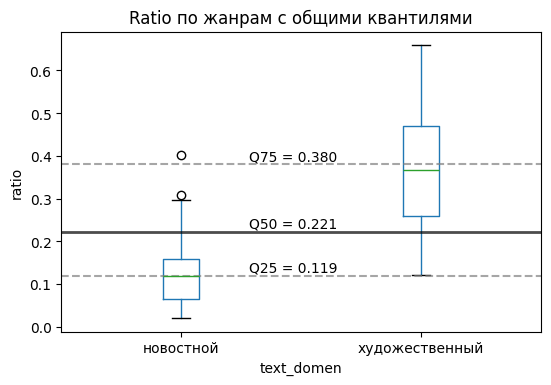

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data1 = data.copy()

q25, q50, q75 = data1['ratio'].quantile([0.25, 0.5, 0.75])
print(f"Q25={q25:.3f}  Q50={q50:.3f}  Q75={q75:.3f}\n")

data1['zone'] = pd.cut(data1['ratio'], bins=[-np.inf, q25, q50, q75, np.inf], 
                     labels=['≤Q25', 'Q25–Q50', 'Q50–Q75', '>Q75'])
print(pd.crosstab(data1['text_domen'], data1['zone'], margins=True))

data1.boxplot(column='ratio', by='text_domen', grid=False, figsize=(6,4))

# Общие квантили и медиана
plt.axhline(y=q25, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=q50, color='black', linestyle='-', linewidth=2, alpha=0.7)
plt.axhline(y=q75, color='gray', linestyle='--', alpha=0.7)

# Подписи справа, чуть выше линий
x_pos = len(data1['text_domen'].unique()) - 0.35
plt.text(x_pos, q25 + 0.01, f'Q25 = {q25:.3f}', ha='right')
plt.text(x_pos, q50 + 0.01, f'Q50 = {q50:.3f}', ha='right')
plt.text(x_pos, q75 + 0.01, f'Q75 = {q75:.3f}', ha='right')

plt.suptitle('')
plt.title('Ratio по жанрам с общими квантилями')
plt.ylabel('ratio')
plt.show()

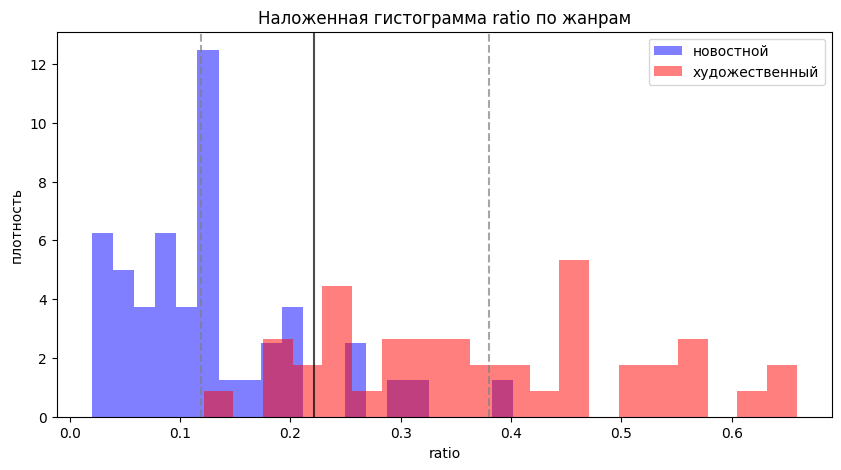

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

q25, q50, q75 = data['ratio'].quantile([0.25, 0.5, 0.75])

plt.figure(figsize=(10,5))

# Гистограмма с прозрачностью
for genre, color in [('новостной', 'blue'), ('художественный', 'red')]:
    subset = data[data['text_domen'] == genre]
    plt.hist(subset['ratio'], bins=20, alpha=0.5, color=color, label=genre, density=True)

# Линии квантилей
plt.axvline(q25, color='gray', linestyle='--', alpha=0.7)
plt.axvline(q50, color='black', linestyle='-', alpha=0.7)
plt.axvline(q75, color='gray', linestyle='--', alpha=0.7)

plt.xlabel('ratio')
plt.ylabel('плотность')
plt.title('Наложенная гистограмма ratio по жанрам')
plt.legend()
plt.show()
# плотность (глажженный)

In [49]:
cv = data['len'].std() / data['len'].mean()

literal = data[data['text_domen'] == 'художественный']
news = data[data['text_domen'] == 'новостной']

cv_literal = literal['len'].std() / literal['len'].mean()
cv_news = news['len'].std() / news['len'].mean()

print(cv, cv_literal, cv_news)

0.24614077001738738 0.2179303920448528 0.27171982530389116
